# Laboratorio 2 — LSTM para series de Región dos
Basado en el análisis del Lab 1, se trabajan las 3 series de **Región dos** con mayor volumen acumulado:
- América Del Centro
- América Del Norte
- Europa

Incisos cubiertos: **1.1** (preparación train/test) y **1.2** (al menos 2 modelos LSTM por serie con tuneo).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from itertools import product

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

### Inciso 1.1 — Carga y preparación de las series

Misma base, mismo filtro (Turista + Excursionista) y misma división 70/30 que en Lab 1.

In [2]:
df = pd.read_csv("./df/Base_Migracion_2009-2026jun.csv")
df['Viajero'] = pd.to_numeric(df['Viajero'], errors='coerce')

df_ts = df[df["Tipo de Viajero"].isin(["Turista", "Excursionista"])].copy()
df_ts["Fecha"] = pd.to_datetime(
    dict(year=df_ts["Año"], month=df_ts["Mes cod"], day=1)
)
calendario = pd.date_range(df_ts["Fecha"].min(), df_ts["Fecha"].max(), freq="MS")

def serie_mensual(datos, filtro_col, filtro_val):
    subset = datos[datos[filtro_col] == filtro_val]
    return (
        subset.groupby("Fecha")["Viajero"].sum()
        .reindex(calendario, fill_value=0)
        .astype(float)
        .asfreq("MS")
    )

top3_regiones = ["América Del Centro", "América Del Norte", "Europa"]
series = {
    r: serie_mensual(df_ts, "Región dos", r) for r in top3_regiones
}

In [3]:
def dividir_serie(serie, proporcion=0.70):
    corte = int(np.floor(len(serie) * proporcion))
    return serie.iloc[:corte].copy(), serie.iloc[corte:].copy()

splits = {}
for nombre, serie in series.items():
    train, test = dividir_serie(serie)
    splits[nombre] = {"serie": serie, "train": train, "test": test}

resumen = pd.DataFrame(
    {
        "Región": list(series.keys()),
        "Inicio": [s.index.min() for s in series.values()],
        "Fin": [s.index.max() for s in series.values()],
        "Frecuencia": [s.index.freqstr for s in series.values()],
        "n_train": [splits[n]["train"].shape[0] for n in series],
        "n_test": [splits[n]["test"].shape[0] for n in series],
        "Total": [s.shape[0] for s in series.values()],
    }
)
display(resumen.style.hide(axis="index"))

Región,Inicio,Fin,Frecuencia,n_train,n_test,Total
América Del Centro,2009-01-01 00:00:00,2026-06-01 00:00:00,MS,147,63,210
América Del Norte,2009-01-01 00:00:00,2026-06-01 00:00:00,MS,147,63,210
Europa,2009-01-01 00:00:00,2026-06-01 00:00:00,MS,147,63,210


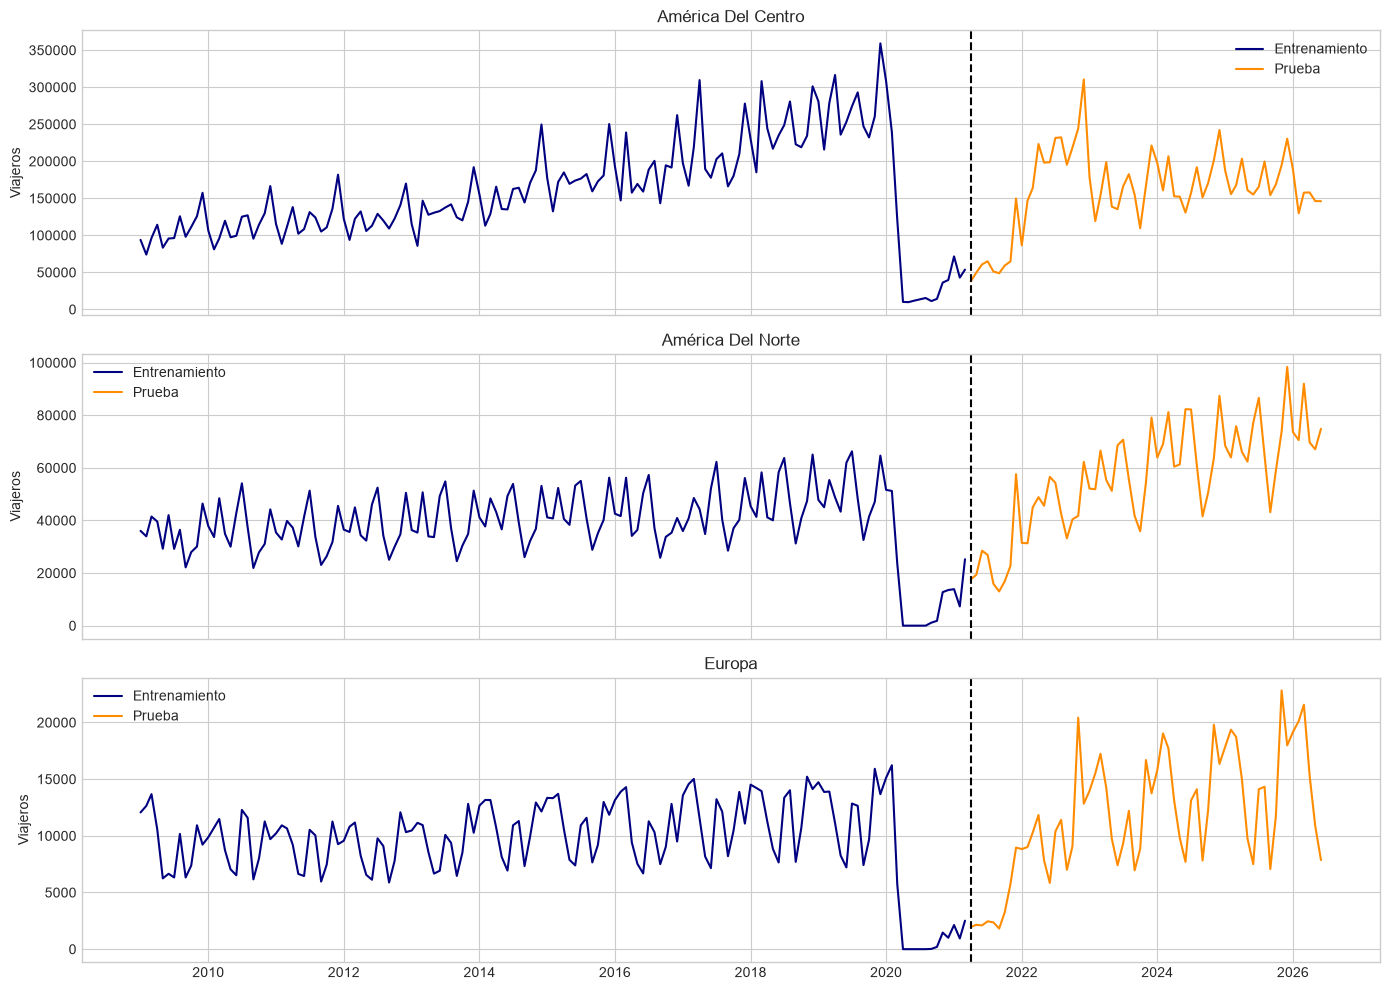

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for i, (nombre, s) in enumerate(splits.items()):
    axes[i].plot(s["train"], color="navy", label="Entrenamiento")
    axes[i].plot(s["test"], color="darkorange", label="Prueba")
    axes[i].axvline(s["test"].index[0], color="black", ls="--")
    axes[i].set_title(nombre)
    axes[i].set_ylabel("Viajeros")
    axes[i].legend()
plt.tight_layout()
plt.show()

### Inciso 1.2 — Modelos LSTM con tuneo

Para cada una de las 3 series se construyen secuencias supervisadas con ventana de 12 meses (estacionalidad anual). Se prueban **2 arquitecturas** por serie con búsqueda de hiperparámetros:

| Modelo | Capas LSTM | Units   | Dropout | Optimizador |
|--------|-----------|---------|---------|-------------|
| A      | 1 capa     | 32 o 64 | 0.1-0.2 | Adam        |
| B      | 2 capas    | 64+32   | 0.2-0.3 | Adam/RMSprop |

In [5]:
def crear_secuencias(serie, ventana=12):
    X, y = [], []
    for i in range(len(serie) - ventana):
        X.append(serie.iloc[i:i+ventana].values)
        y.append(serie.iloc[i+ventana])
    return np.array(X), np.array(y)

def construir_lstm(ventana, units, n_capas, dropout, lr, optimizador="adam"):
    modelo = Sequential()
    if n_capas == 1:
        modelo.add(LSTM(units, input_shape=(ventana, 1)))
        if dropout > 0:
            modelo.add(Dropout(dropout))
    else:
        modelo.add(LSTM(units, return_sequences=True, input_shape=(ventana, 1)))
        if dropout > 0:
            modelo.add(Dropout(dropout))
        modelo.add(LSTM(max(16, units//2)))
        if dropout > 0:
            modelo.add(Dropout(dropout))
    modelo.add(Dense(1))
    opt = Adam(learning_rate=lr) if optimizador == "adam" else RMSprop(learning_rate=lr)
    modelo.compile(optimizer=opt, loss="mse", metrics=["mae"])
    return modelo

def entrenar_lstm(modelo, X_train, y_train, X_val, y_val, epochs, batch_size):
    early = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    hist = modelo.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early],
        verbose=0,
    )
    return hist

def evaluar_en_test(modelo, scaler_y, X_test, y_test_orig):
    pred_scaled = modelo.predict(X_test, verbose=0).flatten()
    pred_orig = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    pred_orig = np.maximum(0, pred_orig)
    mae = mean_absolute_error(y_test_orig, pred_orig)
    rmse = np.sqrt(mean_squared_error(y_test_orig, pred_orig))
    return pred_orig, mae, rmse

In [6]:
VENTANA = 12
configs = [
    # (nombre, n_capas, units, dropout, lr, optimizador, epochs, batch_size)
    ("LSTM-1A", 1, 32, 0.1, 0.001, "adam", 80, 16),
    ("LSTM-1B", 1, 64, 0.2, 0.01, "adam", 80, 32),
    ("LSTM-2A", 2, 64, 0.2, 0.001, "adam", 100, 16),
    ("LSTM-2B", 2, 128, 0.3, 0.0005, "rmsprop", 100, 32),
]

resultados = []
predicciones = {}

for nombre_serie, s in splits.items():
    train, test = s["train"], s["test"]
    if len(train) <= VENTANA:
        continue

    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()
    test_scaled = scaler.transform(test.values.reshape(-1, 1)).flatten()

    serie_scaled = pd.Series(
        np.concatenate([train_scaled, test_scaled]),
        index=pd.date_range(train.index[0], test.index[-1], freq="MS"),
    )

    X_all, y_all = crear_secuencias(serie_scaled, VENTANA)
    X_all = X_all.reshape((X_all.shape[0], X_all.shape[1], 1))

    n_train_seq = len(train) - VENTANA
    X_tr, y_tr = X_all[:n_train_seq], y_all[:n_train_seq]
    X_te, y_te = X_all[n_train_seq:], y_all[n_train_seq:]
    y_te_orig = test.values

    if len(X_te) == 0:
        continue

    predicciones[nombre_serie] = {}

    for nombre_cfg, n_capas, units, dropout, lr, optim, epochs, bs in configs:
        modelo = construir_lstm(VENTANA, units, n_capas, dropout, lr, optim)
        hist = entrenar_lstm(modelo, X_tr, y_tr, X_te, y_te, epochs, bs)
        pred, mae, rmse = evaluar_en_test(modelo, scaler, X_te, y_te_orig)

        resultados.append({
            "Serie": nombre_serie,
            "Modelo": nombre_cfg,
            "Capas": n_capas,
            "Units": units,
            "Dropout": dropout,
            "LR": lr,
            "Optimizer": optim,
            "Epochs": len(hist.history["loss"]),
            "Batch": bs,
            "MAE": mae,
            "RMSE": rmse,
            "Loss_final": hist.history["loss"][-1],
            "Val_loss_final": hist.history["val_loss"][-1],
        })
        predicciones[nombre_serie][nombre_cfg] = pred

    print(f"Completado: {nombre_serie}")

Completado: América Del Centro


Completado: América Del Norte


Completado: Europa


In [7]:
tabla_resultados = pd.DataFrame(resultados)

display(
    tabla_resultados.style.format({
        "MAE": "{:,.0f}",
        "RMSE": "{:,.0f}",
        "Loss_final": "{:.6f}",
        "Val_loss_final": "{:.6f}",
    })
)

,Serie,Modelo,Capas,Units,Dropout,LR,Optimizer,Epochs,Batch,MAE,RMSE,Loss_final,Val_loss_final
0,América Del Centro,LSTM-1A,1,32,0.100000,0.001000,adam,80,16,"29,521","37,013",0.016405,0.011372
1,América Del Centro,LSTM-1B,1,64,0.200000,0.010000,adam,77,32,"27,271","34,221",0.012143,0.009942
2,América Del Centro,LSTM-2A,2,64,0.200000,0.001000,adam,67,16,"30,432","38,527",0.019181,0.013730
3,América Del Centro,LSTM-2B,2,128,0.300000,0.000500,rmsprop,80,32,"31,669","40,304",0.021304,0.014257
4,América Del Norte,LSTM-1A,1,32,0.100000,0.001000,adam,14,16,"11,271","14,045",0.041028,0.066774
5,América Del Norte,LSTM-1B,1,64,0.200000,0.010000,adam,13,32,"10,629","13,617",0.034858,0.064506
6,América Del Norte,LSTM-2A,2,64,0.200000,0.001000,adam,12,16,"11,724","14,604",0.038589,0.068115
7,América Del Norte,LSTM-2B,2,128,0.300000,0.000500,rmsprop,17,32,"9,769","12,274",0.040397,0.035998
8,Europa,LSTM-1A,1,32,0.100000,0.001000,adam,14,16,"3,495","4,157",0.043022,0.074387
9,Europa,LSTM-1B,1,64,0.200000,0.010000,adam,45,32,"2,798","3,577",0.024015,0.057344


In [8]:
mejores = (
    tabla_resultados.loc[tabla_resultados.groupby("Serie")["RMSE"].idxmin()]
    .reset_index(drop=True)
)
print("=== Mejor modelo por serie (menor RMSE) ===")
display(
    mejores.style.format({
        "MAE": "{:,.0f}", "RMSE": "{:,.0f}",
        "Loss_final": "{:.6f}", "Val_loss_final": "{:.6f}",
    })
)

=== Mejor modelo por serie (menor RMSE) ===


,Serie,Modelo,Capas,Units,Dropout,LR,Optimizer,Epochs,Batch,MAE,RMSE,Loss_final,Val_loss_final
0,América Del Centro,LSTM-1B,1,64,0.200000,0.010000,adam,77,32,"27,271","34,221",0.012143,0.009942
1,América Del Norte,LSTM-2B,2,128,0.300000,0.000500,rmsprop,17,32,"9,769","12,274",0.040397,0.035998
2,Europa,LSTM-1B,1,64,0.200000,0.010000,adam,45,32,"2,798","3,577",0.024015,0.057344


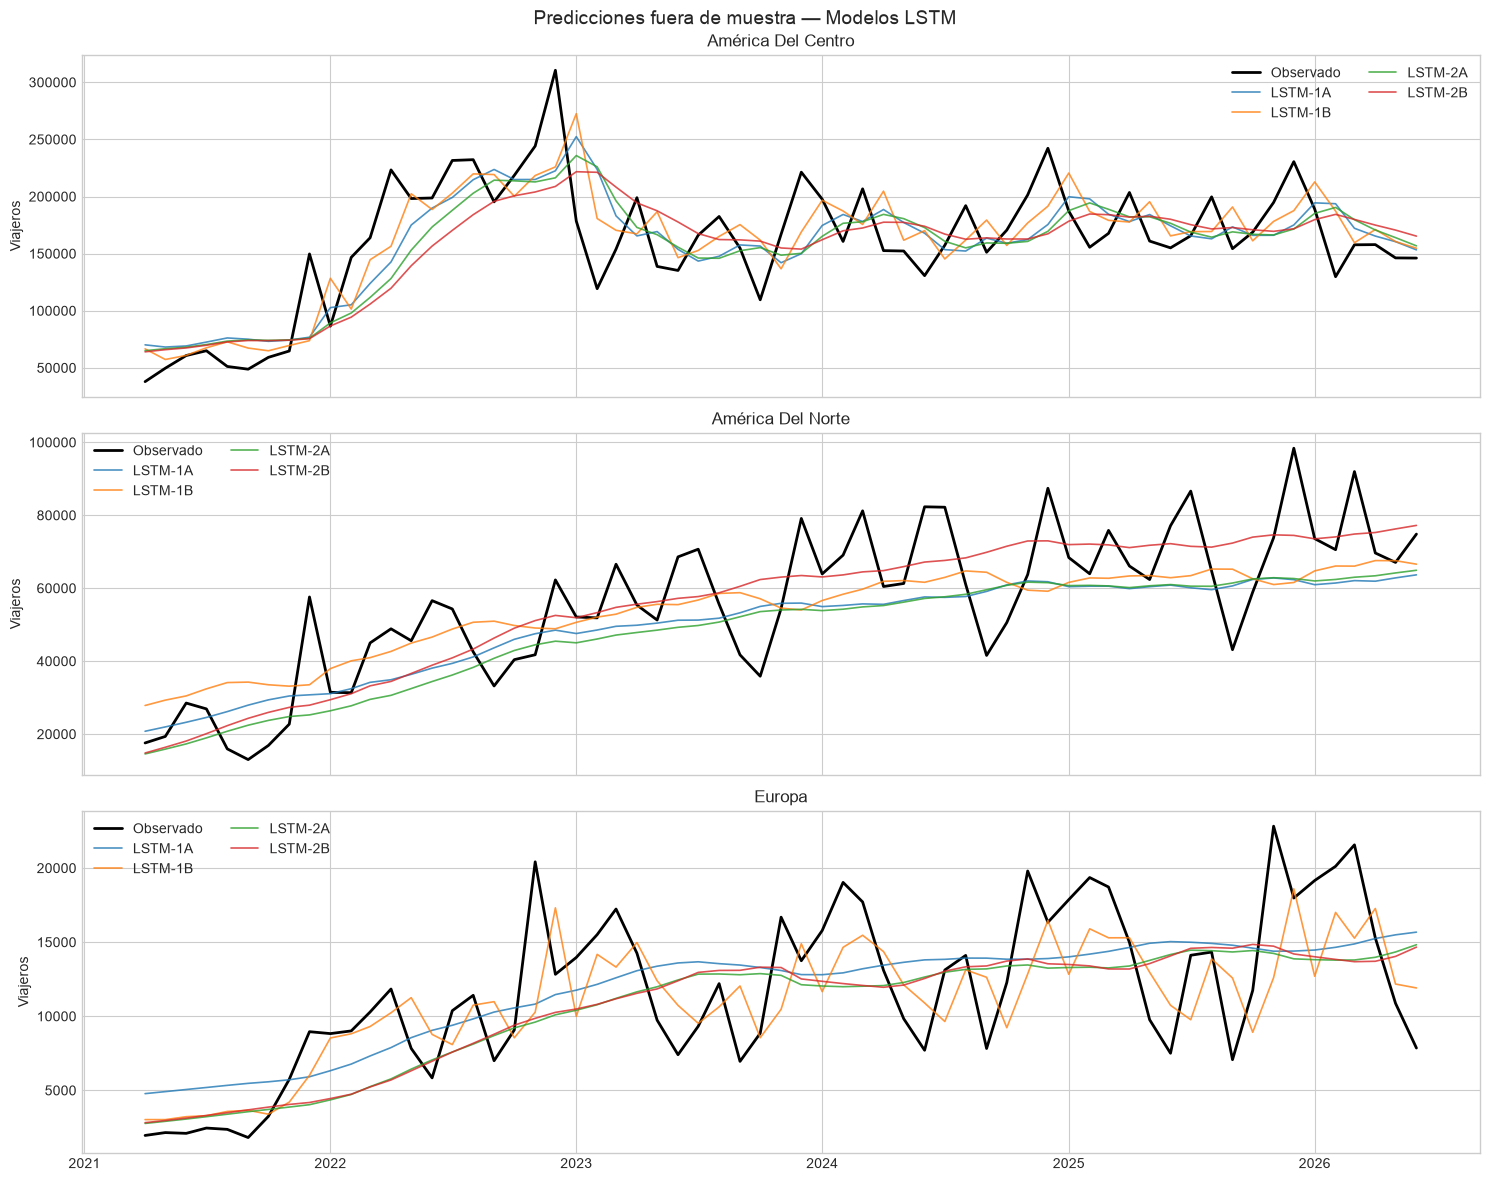

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

for i, (nombre_serie, s) in enumerate(splits.items()):
    test = s["test"]
    test_plot = test

    axes[i].plot(test_plot.index, test_plot.values, color="black", lw=2, label="Observado")

    for cfg_name, pred in predicciones.get(nombre_serie, {}).items():
        if len(pred) == len(test_plot):
            axes[i].plot(test_plot.index, pred, lw=1.2, alpha=0.8, label=cfg_name)

    axes[i].set_title(nombre_serie)
    axes[i].set_ylabel("Viajeros")
    axes[i].legend(ncol=2)

plt.suptitle("Predicciones fuera de muestra — Modelos LSTM", fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
print("Resumen de resultados por serie y configuración:\n")
for nombre_serie in series:
    sub = tabla_resultados[tabla_resultados["Serie"] == nombre_serie].sort_values("RMSE")
    print(f"{nombre_serie}:")
    for _, row in sub.iterrows():
        marca = " <<< MEJOR" if row["RMSE"] == sub["RMSE"].min() else ""
        print(
            f"  {row['Modelo']:12s} | MAE={row['MAE']:>8,.0f} | "
            f"RMSE={row['RMSE']:>8,.0f} | Capas={row['Capas']} | "
            f"Units={row['Units']} | Drop={row['Dropout']} | "
            f"LR={row['LR']} | {row['Optimizer']}{marca}"
        )
    print()

Resumen de resultados por serie y configuración:

América Del Centro:
  LSTM-1B      | MAE=  27,271 | RMSE=  34,221 | Capas=1 | Units=64 | Drop=0.2 | LR=0.01 | adam <<< MEJOR
  LSTM-1A      | MAE=  29,521 | RMSE=  37,013 | Capas=1 | Units=32 | Drop=0.1 | LR=0.001 | adam
  LSTM-2A      | MAE=  30,432 | RMSE=  38,527 | Capas=2 | Units=64 | Drop=0.2 | LR=0.001 | adam
  LSTM-2B      | MAE=  31,669 | RMSE=  40,304 | Capas=2 | Units=128 | Drop=0.3 | LR=0.0005 | rmsprop

América Del Norte:
  LSTM-2B      | MAE=   9,769 | RMSE=  12,274 | Capas=2 | Units=128 | Drop=0.3 | LR=0.0005 | rmsprop <<< MEJOR
  LSTM-1B      | MAE=  10,629 | RMSE=  13,617 | Capas=1 | Units=64 | Drop=0.2 | LR=0.01 | adam
  LSTM-1A      | MAE=  11,271 | RMSE=  14,045 | Capas=1 | Units=32 | Drop=0.1 | LR=0.001 | adam
  LSTM-2A      | MAE=  11,724 | RMSE=  14,604 | Capas=2 | Units=64 | Drop=0.2 | LR=0.001 | adam

Europa:
  LSTM-1B      | MAE=   2,798 | RMSE=   3,577 | Capas=1 | Units=64 | Drop=0.2 | LR=0.01 | adam <<< MEJOR
